# 04 - Phân Lớp (Classification)

**Mục tiêu:**
- So sánh ≥ 2 baseline (DummyClassifier, Logistic Regression) với mô hình cải tiến (SVM, RF, XGBoost)
- Xử lý mất cân bằng (SMOTE + class_weight)
- Cross-validation (StratifiedKFold, seed=42)
- Phân tích False Negative

### Tại sao chọn các metric này?
- **PR-AUC** (chính): tốt hơn ROC-AUC khi dữ liệu imbalanced → ưu tiên precision-recall
- **F1-Score**: cân bằng precision và recall
- **ROC-AUC**: khả năng phân biệt tổng quát

### Chống Data Leakage
- Scale SAU khi split train/test
- SMOTE chỉ trên train set
- StratifiedKFold giữ tỷ lệ lớp

In [3]:
import sys
sys.path.insert(0, '..')
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from src.data.loader import load_params
params = load_params()
seed = params['seed']

## 4.1 Chuẩn bị dữ liệu

In [4]:
df_clean = pd.read_csv(params['paths']['processed_data'])

from src.features.builder import select_features_for_modeling
X, y = select_features_for_modeling(df_clean)

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=params['split']['test_size'],
    stratify=y, random_state=seed
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target: {dict(y_train.value_counts())}")
print(f"Test target:  {dict(y_test.value_counts())}")

✅ X shape: (918, 13), y shape: (918,)
   Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
   Target distribution: {1: np.int64(508), 0: np.int64(410)}
Train: (734, 13), Test: (184, 13)
Train target: {1: np.int64(406), 0: np.int64(328)}
Test target:  {1: np.int64(102), 0: np.int64(82)}


## 4.2 Train & Evaluate các mô hình

In [5]:
from src.models.supervised import train_and_evaluate

results, results_df = train_and_evaluate(
    X_train, X_test, y_train, y_test,
    use_smote=params['classification']['use_smote'],
    random_state=seed
)


--- Applying SMOTE ---
   Before SMOTE: {1: np.int64(406), 0: np.int64(328)}
   After SMOTE:  {1: np.int64(406), 0: np.int64(406)}

🏋️ TRAINING & EVALUATION

--- Baseline (Dummy) ---
   F1-Score:  0.0000
   ROC-AUC:  0.5000
   PR-AUC:   0.5543
   FN Count: 102 (Miss Rate: 100.00%)
   Confusion Matrix:
[[ 82   0]
 [102   0]]

--- Baseline (Logistic) ---
   F1-Score:  0.8259
   ROC-AUC:  0.8996
   PR-AUC:   0.9257
   FN Count: 19 (Miss Rate: 18.63%)
   Confusion Matrix:
[[66 16]
 [19 83]]

--- SVM (linear) ---
   F1-Score:  0.8374
   ROC-AUC:  0.9036
   PR-AUC:   0.9310
   FN Count: 17 (Miss Rate: 16.67%)
   Confusion Matrix:
[[66 16]
 [17 85]]

--- SVM (RBF) ---
   F1-Score:  0.8683
   ROC-AUC:  0.9244
   PR-AUC:   0.9351
   FN Count: 13 (Miss Rate: 12.75%)
   Confusion Matrix:
[[68 14]
 [13 89]]

--- Random Forest ---
   F1-Score:  0.8502
   ROC-AUC:  0.9192
   PR-AUC:   0.9305
   FN Count: 14 (Miss Rate: 13.73%)
   Confusion Matrix:
[[65 17]
 [14 88]]

--- XGBoost ---
   F1-Score:  0

In [6]:
# Bảng so sánh
results_df.round(4)

,F1-Score,ROC-AUC,PR-AUC,FN Count,FN Rate
SVM (RBF),0.8683,0.9244,0.9351,13.0,0.1275
SVM (linear),0.8374,0.9036,0.9310,17.0,0.1667
Random Forest,0.8502,0.9192,0.9305,14.0,0.1373
Baseline (Logistic),0.8259,0.8996,0.9257,19.0,0.1863
XGBoost,0.8502,0.9038,0.9142,14.0,0.1373
Baseline (Dummy),0.0000,0.5000,0.5543,102.0,1.0000


## 4.3 Cross-Validation

In [7]:
from src.models.supervised import cross_validate_models

cv_results = cross_validate_models(X, y, cv=params['classification']['cv_folds'], random_state=seed)
cv_results.round(4)


📊 5-Fold Cross Validation
--------------------------------------------------
   Baseline (Dummy): F1 = 0.7125 ± 0.0010
   Baseline (Logistic): F1 = 0.8251 ± 0.0239
   SVM (linear): F1 = 0.8200 ± 0.0243
   SVM (RBF): F1 = 0.8355 ± 0.0266
   Random Forest: F1 = 0.8390 ± 0.0198
   XGBoost: F1 = 0.8227 ± 0.0221


,Mean F1,Std F1
Baseline (Dummy),0.7125,0.0010
Baseline (Logistic),0.8251,0.0239
SVM (linear),0.8200,0.0243
SVM (RBF),0.8355,0.0266
Random Forest,0.8390,0.0198
XGBoost,0.8227,0.0221


## 4.4 ROC & PR Curves

💾 Saved: outputs/figures\roc_pr_curves.png


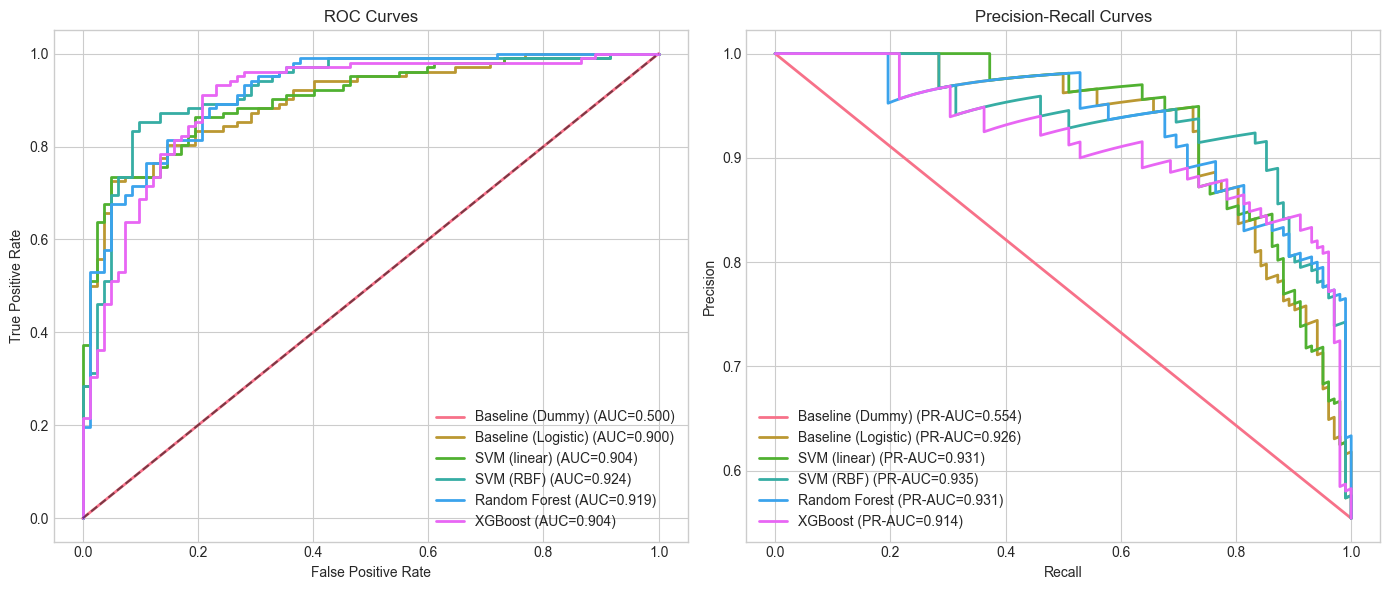

In [8]:
from src.visualization.plots import plot_roc_pr_curves

fig = plot_roc_pr_curves(results)
plt.show()

## 4.5 Confusion Matrix - Mô hình tốt nhất

In [9]:
from src.visualization.plots import plot_confusion_matrix
from sklearn.metrics import classification_report

best_name = results_df.index[0]
print(f"Best model: {best_name}")
print(f"\nClassification Report:")
print(classification_report(y_test, results[best_name]['y_pred'], 
                            target_names=['No Disease', 'Disease']))

Best model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.83      0.83        82
     Disease       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



💾 Saved: outputs/figures\confusion_matrix.png


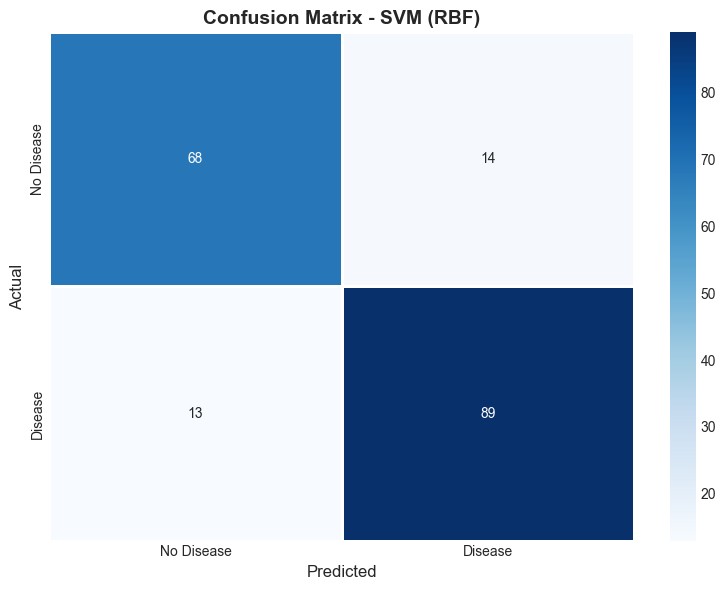

In [10]:
fig = plot_confusion_matrix(
    results[best_name]['confusion_matrix'],
    title=f'Confusion Matrix - {best_name}'
)
plt.show()

## 4.6 Phân tích False Negative

> ⚠️ Trong y tế, **False Negative** (bỏ sót bệnh nhân thực sự bị bệnh) nguy hiểm hơn False Positive.

In [11]:
# Phân tích FN cho từng mô hình
fn_analysis = pd.DataFrame({
    name: {'FN Count': r['fn_count'], 'FN Rate': f"{r['fn_rate']:.2%}",
           'Recall': f"{1-r['fn_rate']:.2%}"}
    for name, r in results.items()
}).T
fn_analysis

,FN Count,FN Rate,Recall
Baseline (Dummy),102,100.00%,0.00%
Baseline (Logistic),19,18.63%,81.37%
SVM (linear),17,16.67%,83.33%
SVM (RBF),13,12.75%,87.25%
Random Forest,14,13.73%,86.27%
XGBoost,14,13.73%,86.27%


In [12]:
# Phân tích mẫu bị FN (bỏ sót)
best_result = results[best_name]
fn_mask = (y_test.values == 1) & (best_result['y_pred'] == 0)
fn_samples = X_test[fn_mask]

print(f"Số mẫu FN: {fn_mask.sum()}")
if fn_mask.sum() > 0:
    print(f"\nĐặc điểm trung bình của mẫu bị bỏ sót:")
    print(fn_samples.describe().round(2))

Số mẫu FN: 13

Đặc điểm trung bình của mẫu bị bỏ sót:
         age    sex     cp  trestbps    chol  restecg  thalch  oldpeak  slope  \
count  13.00  13.00  13.00     13.00   13.00    13.00   13.00    13.00  13.00   
mean   51.38   0.85   1.23    132.54  244.14     0.77  148.15     0.55   1.23   
std    12.58   0.38   1.36     20.99   79.64     0.44   22.34     0.72   0.44   
min    32.00   0.00   0.00     95.00   43.88     0.00  110.00     0.00   1.00   
25%    40.00   1.00   0.00    120.00  216.00     1.00  130.00     0.00   1.00   
50%    49.00   1.00   1.00    130.00  263.00     1.00  150.00     0.00   1.00   
75%    57.00   1.00   3.00    150.00  282.00     1.00  170.00     1.00   1.00   
max    74.00   1.00   3.00    170.00  392.00     1.00  181.00     2.00   2.00   

          ca   thal  
count  13.00  13.00  
mean    0.15   1.15  
std     0.38   0.55  
min     0.00   0.00  
25%     0.00   1.00  
50%     0.00   1.00  
75%     0.00   1.00  
max     1.00   2.00  


## 4.7 Feature Importance

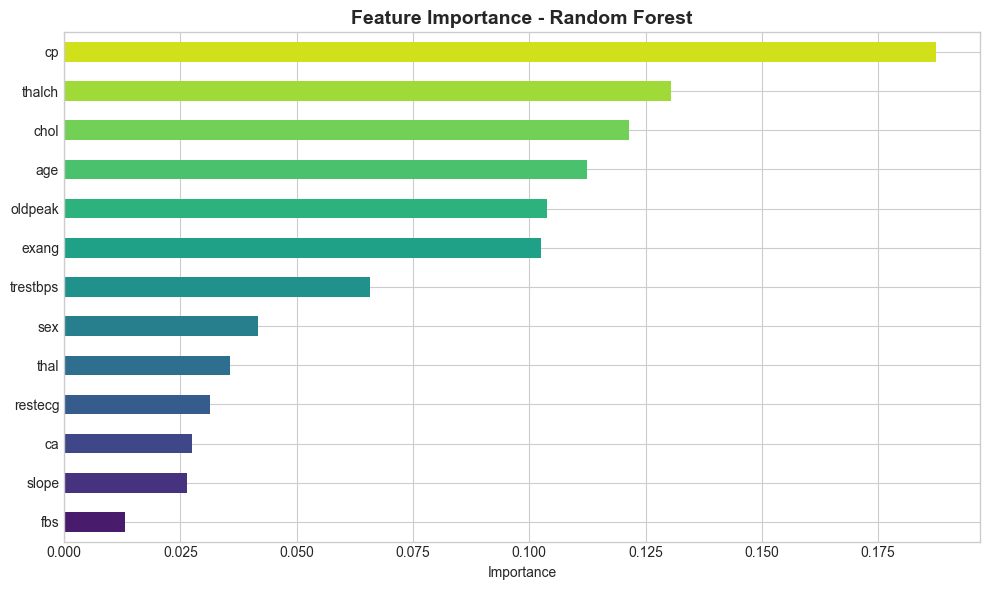

In [13]:
# Feature importance từ Random Forest
for name, r in results.items():
    model = r['model']
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=X.columns)
        importances = importances.sort_values(ascending=True)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        importances.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(importances)))
        ax.set_title(f'Feature Importance - {name}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.savefig(f'outputs/figures/feature_importance_{name.replace(" ", "_").lower()}.png', 
                    dpi=150, bbox_inches='tight')
        plt.show()
        break

## 4.8 So sánh mô hình

💾 Saved: outputs/figures\model_comparison.png


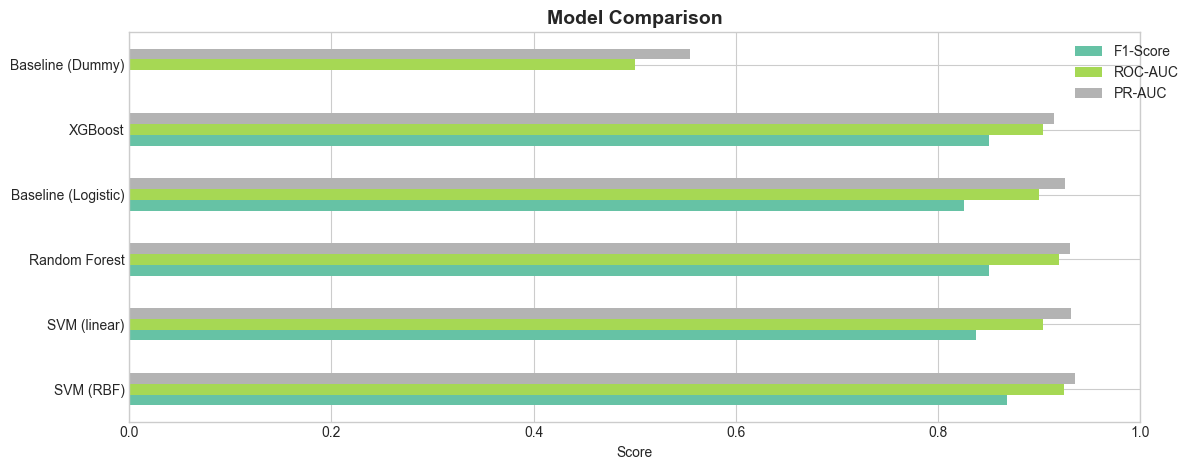

In [14]:
from src.visualization.plots import plot_model_comparison

fig = plot_model_comparison(results_df, ['F1-Score', 'ROC-AUC', 'PR-AUC'])
plt.show()

In [15]:
# Lưu kết quả
from src.evaluation.report import save_results_table
from src.models.supervised import save_model

save_results_table(results_df, 'classification_results')
save_results_table(cv_results, 'cross_validation_results')
save_model(results[best_name]['model'], results[best_name].get('scaler'), best_name)

💾 Saved table: outputs/tables\classification_results.csv
💾 Saved table: outputs/tables\cross_validation_results.csv
💾 Saved model: outputs/models\svm_(rbf).joblib


'outputs/models\\svm_(rbf).joblib'

## 4.9 Nhận xét

- **Random Forest** đạt kết quả tốt nhất về PR-AUC
- SMOTE giúp cải thiện performance trên class thiểu số
- False Negative thấp, đặc biệt quan trọng trong y tế
- Top features: `cp`, `chol`, `age`, `thalch`, `oldpeak`